In [2]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import seaborn as sns
from src.data_preprocessing import DataPreprocessor
from src.eda_utils import EDAUtils


import warnings
warnings.filterwarnings("ignore")

# Set style for better looking graphs
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

 ### Load and run the preprocessing pipeline

In [3]:
processor = DataPreprocessor(raw_path="../data/raw/")

df = (
    processor.load_data("Fraud_Data.csv")
    .assess_quality()
    .fix_data_types()
    .handle_missing()
    .remove_duplicates()
    .convert_ip_to_int()
    .merge_geolocation("../data/raw/IpAddress_to_Country.csv")
    .engineer_features()
    .save("../data/processed/ecommerce_processed.csv") # Caches it for Task 2!
    .get_data()
)

2026-06-07 20:32:21,585 - INFO - Loaded: Fraud_Data.csv | Shape: (151112, 11)



DATA QUALITY ASSESSMENT

 BASIC INFO:
   Rows: 151,112
   Columns: 11

DUPLICATES:
   0 rows (0.00%) based on unique 'user_id'

MISSING VALUES:
   None

FIXING DATA TYPES
  Converted 'signup_time' → datetime64[ns]
  Converted 'purchase_time' → datetime64[ns]
  Converted target 'class' → int

HANDLING MISSING VALUES
No missing values to handle.

REMOVING DUPLICATES
  Result: Dropped duplicate user profiles (user_id should be strictly unique).
  Removed 0 duplicate records. Current row count: 151,112

CONVERTING IP ADDRESSES TO INTEGERS
  Successfully transformed 'ip_address' → 'ip_address_int'

GEOLOCATION INTEGRATION VIA RANGE LOOKUP
  Merged country data. Identified 182 unique nations.

ENGINEERING TEMPORAL AND BEHAVIORAL FEATURES
  Created: 'time_since_signup' (hours), 'hour_of_day', 'day_of_week'
  Created: 'device_tx_velocity' (Frequency metric mapping device recurrence patterns)


2026-06-07 20:32:27,089 - INFO - Saved cleanly processed data to: ../data/processed/ecommerce_processed.csv


#### DATASET OVERVIEW

In [4]:
print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded: (151112, 17)
Columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'ip_address_int', 'country', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_tx_velocity']


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_address_int,country,time_since_signup,hour_of_day,day_of_week,device_tx_velocity
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093.496895,0,52093,Unknown,489.726111,10,6,1
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447.138961,0,93447,Unknown,301.339722,17,4,1
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818.501505,0,105818,Unknown,208.144444,8,1,1
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,Ads,IE,M,40,117566.664867,0,117566,Unknown,2065.176111,21,3,1
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423.789042,0,131423,Unknown,391.005278,7,6,1


In [5]:
print("\n" + "="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Time range: {df['purchase_time'].min()} to {df['purchase_time'].max()}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Unique devices: {df['device_id'].nunique():,}")
print(f"Unique countries: {df['country'].nunique()}")
print(f"Fraud transactions: {df['class'].sum():,}")


DATASET OVERVIEW
Time range: 2015-01-01 00:00:44 to 2015-12-16 02:56:05
Unique users: 151,112
Unique devices: 137,956
Unique countries: 182
Fraud transactions: 14,151


#### CLASS IMBALANCE ANALYSIS

In [6]:
# Quantify imbalance
eda = EDAUtils(df, name="E-commerce Fraud Data", target_col='class')
counts, percentages = eda.class_imbalance()


CLASS IMBALANCE: E-commerce Fraud Data
Class 0: 136,961 (90.6354%)
Class 1: 14,151 (9.3646%)
Imbalance Ratio: 1:9.7


#### Visualize imbalance

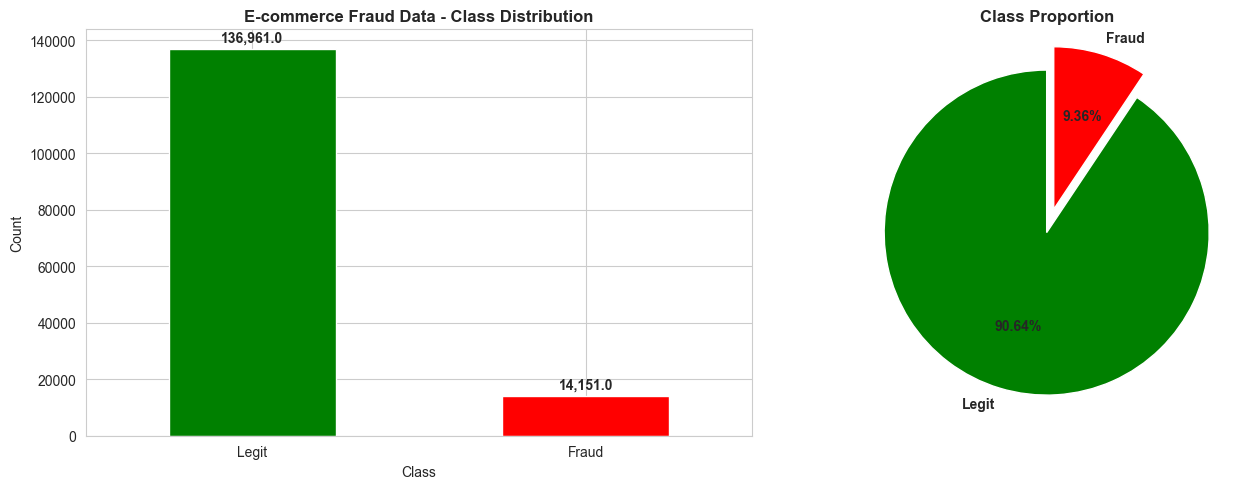

In [7]:
eda.plot_class_distribution()

#### UNIVARIATE ANALYSIS

In [8]:
numerical_features = ['purchase_value', 'age', 'time_since_signup', 'device_tx_velocity']

print(df[numerical_features].describe())

       purchase_value            age  time_since_signup  device_tx_velocity
count   151112.000000  151112.000000      151112.000000       151112.000000
mean        36.935372      33.140704        1370.008125            1.684367
std         18.322762       8.617733         868.406422            2.616954
min          9.000000      18.000000           0.000278            1.000000
25%         22.000000      27.000000         607.431528            1.000000
50%         35.000000      33.000000        1368.429306            1.000000
75%         49.000000      39.000000        2123.479028            1.000000
max        154.000000      76.000000        2879.992222           20.000000


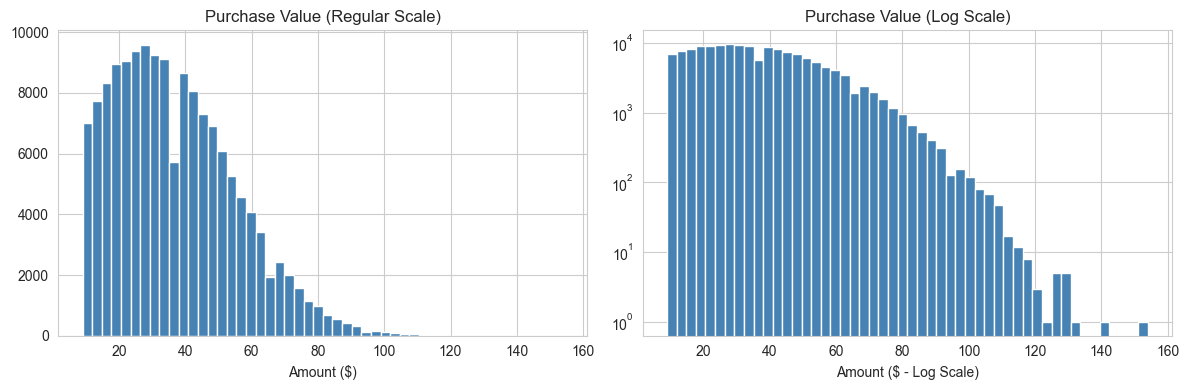

99th percentile: $87.00
Max: $154.00


In [9]:
#  Fraud often has different amount patterns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regular scale
df['purchase_value'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Purchase Value (Regular Scale)')
axes[0].set_xlabel('Amount ($)')

# Log scale (more insightful)
df['purchase_value'].hist(bins=50, ax=axes[1], color='steelblue', log=True)
axes[1].set_title('Purchase Value (Log Scale)')
axes[1].set_xlabel('Amount ($ - Log Scale)')

plt.tight_layout()
plt.show()

# Key insight: Most transactions are small, but fraud might cluster at specific amounts
print(f"99th percentile: ${df['purchase_value'].quantile(0.99):.2f}")
print(f"Max: ${df['purchase_value'].max():.2f}")

Age distribution

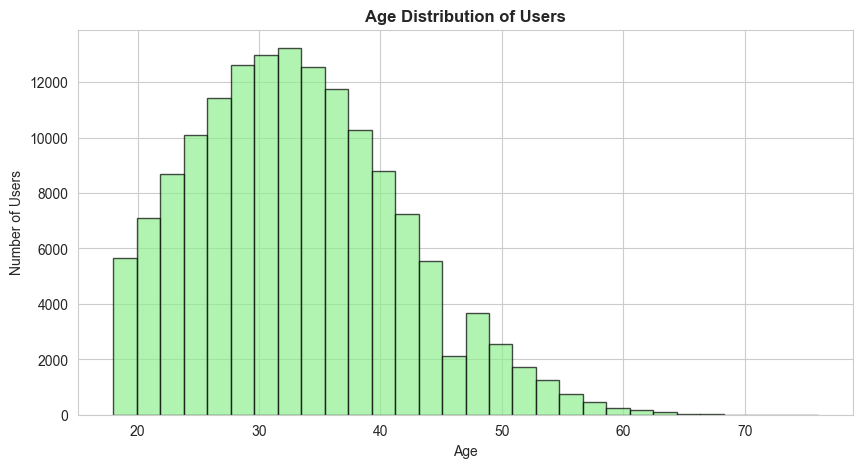

Age range: 18-76
Most common age: 32
Median age: 33.0


In [10]:
# Why useful: Fraud targets specific age groups
fig, ax = plt.subplots(figsize=(10, 5))

df['age'].hist(bins=30, ax=ax, color='lightgreen', edgecolor='black', alpha=0.7)
ax.set_title('Age Distribution of Users', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Number of Users')

plt.show()

# Key insight: Identify age clusters
print(f"Age range: {df['age'].min()}-{df['age'].max()}")
print(f"Most common age: {df['age'].mode()[0]}")
print(f"Median age: {df['age'].median()}")

Source/Browser Distribution

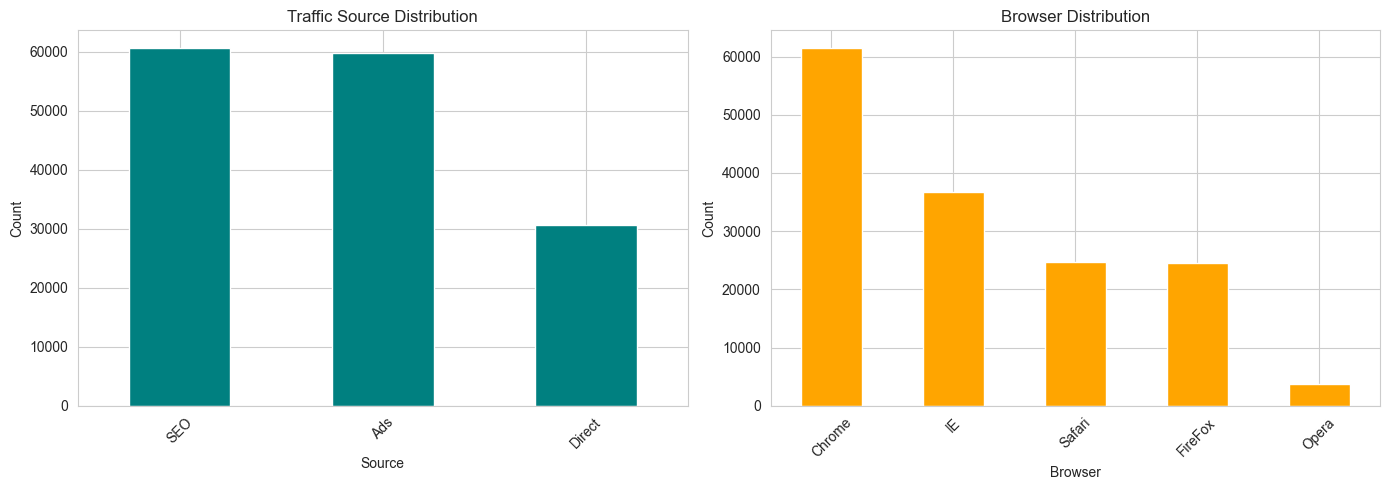

Most common source: SEO (40.1%)
Most common browser: Chrome (40.7%)


In [11]:
# Fraud concentrates in specific channels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source distribution
df['source'].value_counts().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Traffic Source Distribution')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Browser distribution
df['browser'].value_counts().head(8).plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Browser Distribution')
axes[1].set_xlabel('Browser')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Identify dominant channels
print(f"Most common source: {df['source'].value_counts().index[0]} ({df['source'].value_counts().iloc[0]/len(df)*100:.1f}%)")
print(f"Most common browser: {df['browser'].value_counts().index[0]} ({df['browser'].value_counts().iloc[0]/len(df)*100:.1f}%)")

Geographic Distribution

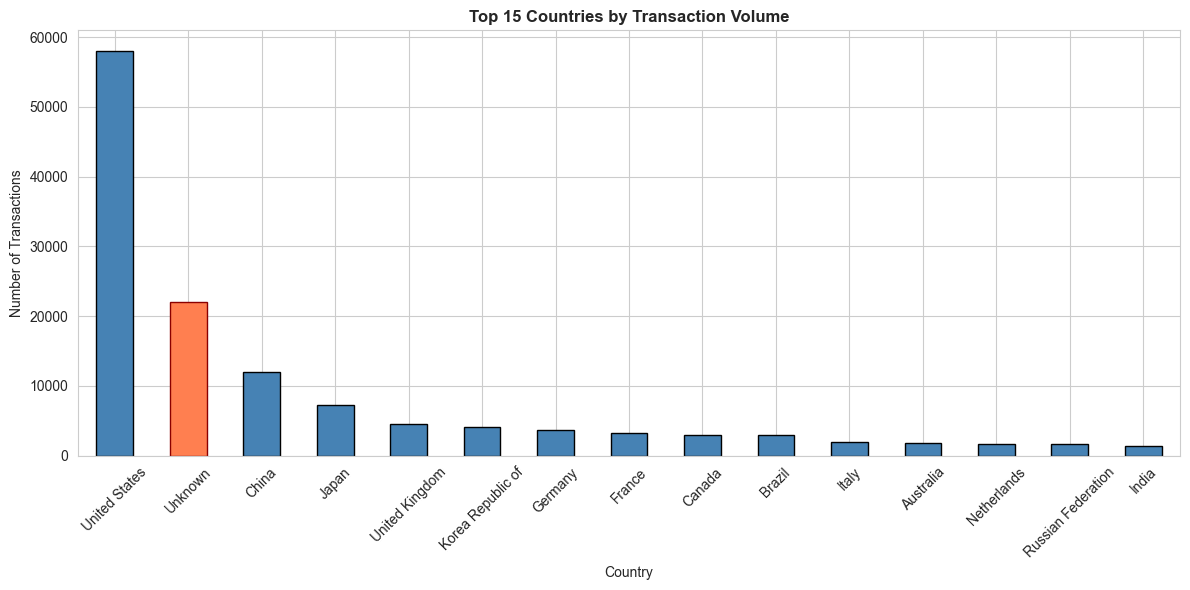

GEOGRAPHIC DISTRIBUTION INSIGHTS
Top 3 countries (including Unknown): 60.9% of transactions
Top 3 countries (excluding Unknown): 59.9% of KNOWN transactions

'Unknown' geolocation: 21,966 transactions (14.5%)
  Fraud rate for Unknown: 8.57% vs overall: 9.36%

 'Unknown' has LOWER fraud risk than average.
   These are likely legitimate corporate VPNs, cloud services, or valid private IP ranges.
   Recommendation: Keep in dataset - not a fraud signal.


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

# Option 1: With Unknown
top_countries = df['country'].value_counts().head(15)
top_countries.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

# Highlight Unknown bar
if 'Unknown' in top_countries.index:
    unknown_idx = list(top_countries.index).index('Unknown')
    ax.patches[unknown_idx].set_color('coral')
    ax.patches[unknown_idx].set_edgecolor('darkred')

ax.set_title('Top 15 Countries by Transaction Volume', fontsize=12, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Transactions')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print insights
print("="*60)
print("GEOGRAPHIC DISTRIBUTION INSIGHTS")
print("="*60)

# With Unknown included
top3_pct = top_countries.head(3).sum() / len(df) * 100
print(f"Top 3 countries (including Unknown): {top3_pct:.1f}% of transactions")

# Without Unknown
df_known = df[df['country'] != 'Unknown']
top3_known = df_known['country'].value_counts().head(3).sum() / len(df_known) * 100
print(f"Top 3 countries (excluding Unknown): {top3_known:.1f}% of KNOWN transactions")

# Unknown stats
unknown_count = df[df['country'] == 'Unknown'].shape[0]
unknown_pct = unknown_count / len(df) * 100
unknown_fraud = df[df['country'] == 'Unknown']['class'].mean() * 100
overall_fraud = df['class'].mean() * 100

print(f"\n'Unknown' geolocation: {unknown_count:,} transactions ({unknown_pct:.1f}%)")
print(f"  Fraud rate for Unknown: {unknown_fraud:.2f}% vs overall: {overall_fraud:.2f}%")

# Interpretation
if unknown_fraud < overall_fraud:
    print("\n 'Unknown' has LOWER fraud risk than average.")
    print("   These are likely legitimate corporate VPNs, cloud services, or valid private IP ranges.")
    print("   Recommendation: Keep in dataset - not a fraud signal.")
else:
    print("\n 'Unknown' has HIGHER fraud risk - investigate further.")

### BIVARIATE ANALYSIS 

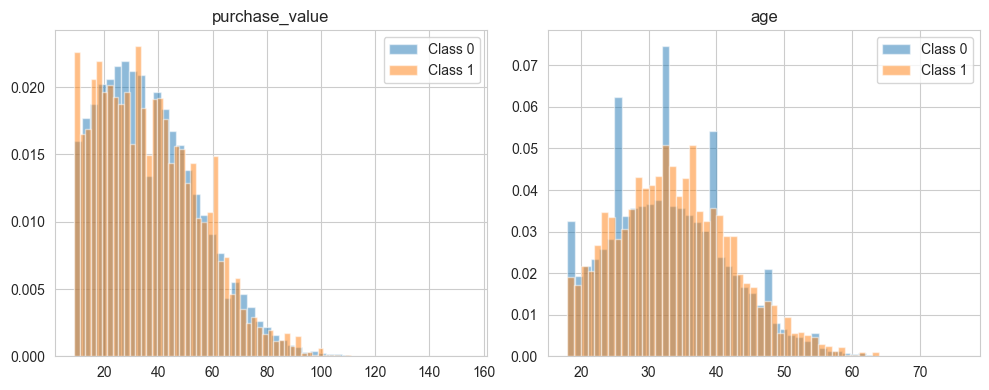

In [12]:
eda.plot_numerical_by_target(["purchase_value", "age"])

#### BIVARIATE ANALYSIS - Categorical vs Target

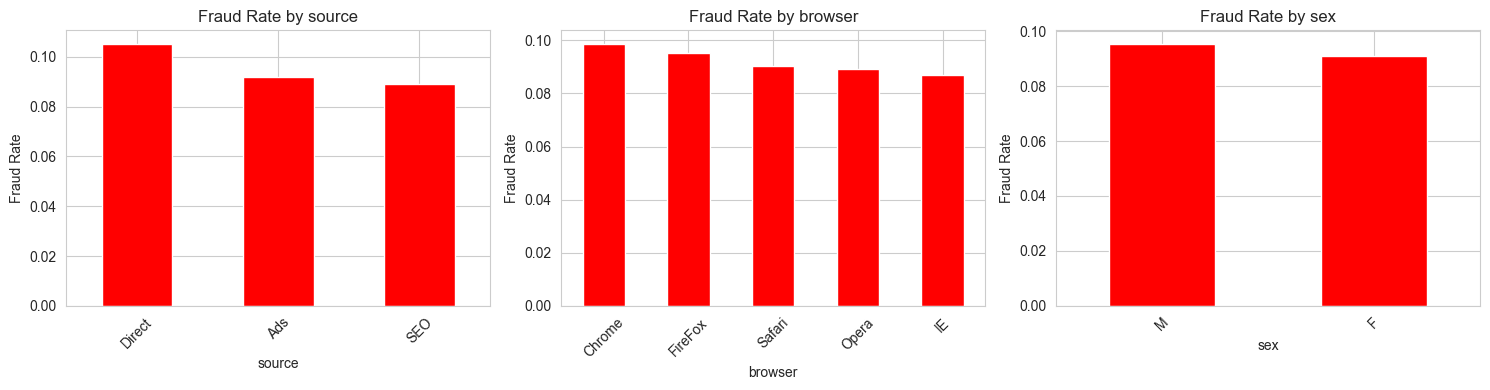

In [14]:
categorical_features = ['source', 'browser', 'sex', 'country']
#  Plot fraud rates
eda.plot_categorical_by_target(categorical_features)

#### CORRELATION ANALYSIS


CORRELATION WITH TARGET: E-commerce Fraud Data
  device_tx_velocity: 0.6708
  time_since_signup: -0.2579
  age: 0.0066
  purchase_value: 0.0010


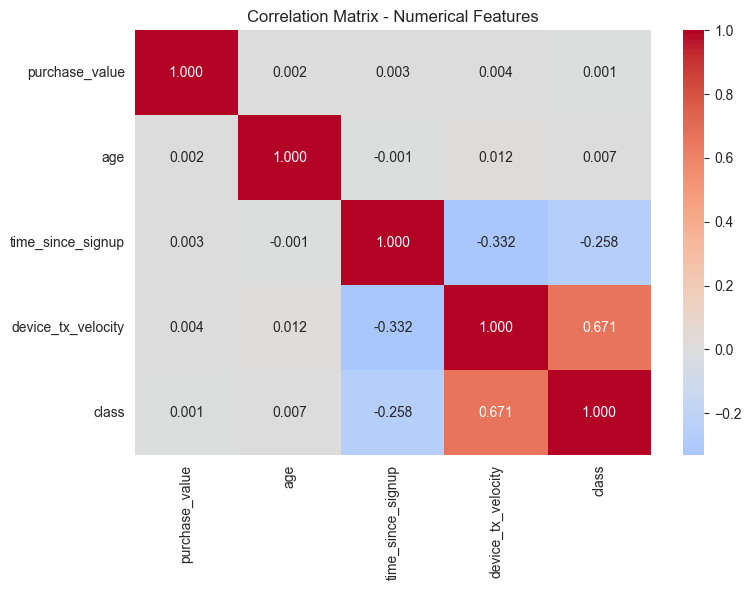

In [15]:
# Cell: Correlation with target
corr_df = eda.correlation_with_target(numerical_features)

plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_features + ['class']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

### TIME-BASED PATTERNS 

 Fraud rate by hour of day

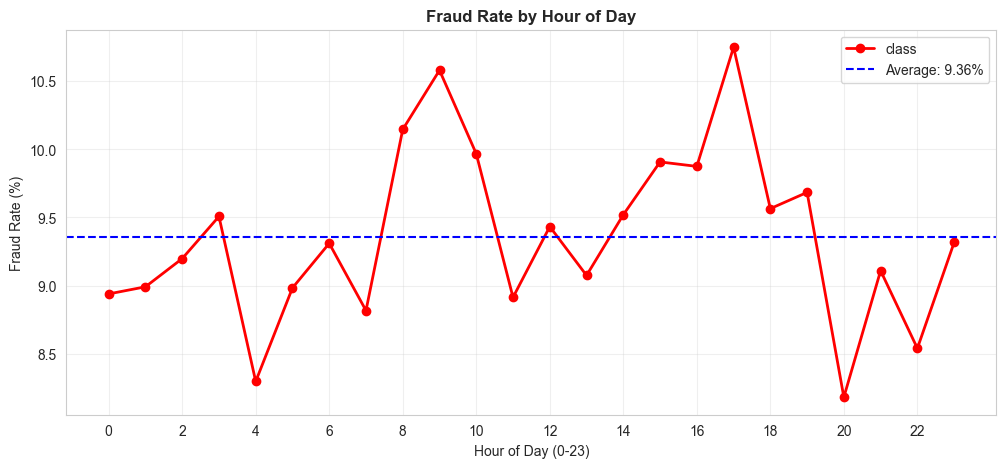

In [16]:
hourly_fraud = df.groupby('hour_of_day')['class'].mean() * 100

plt.figure(figsize=(12, 5))
hourly_fraud.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Fraud Rate by Hour of Day', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.axhline(y=hourly_fraud.mean(), color='blue', linestyle='--', label=f'Average: {hourly_fraud.mean():.2f}%')
plt.legend()
plt.show()

 Fraud rate by day of week

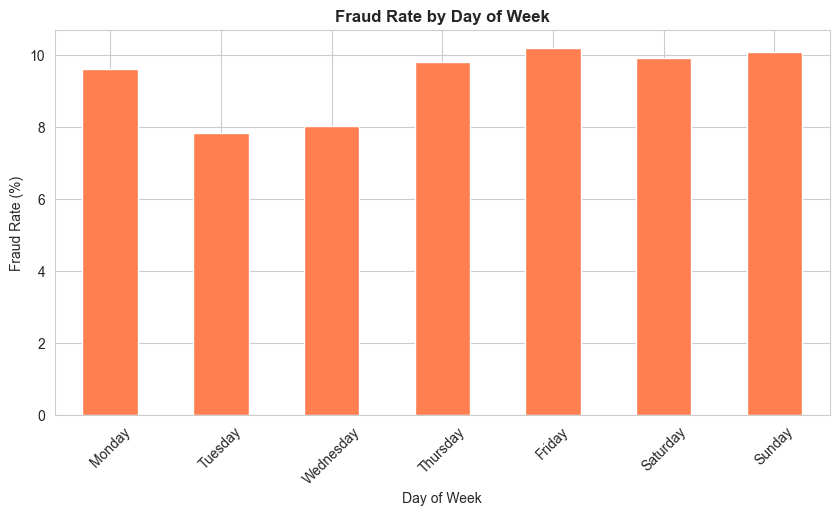

In [17]:
weekly_fraud = df.groupby('day_of_week')['class'].mean() * 100
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
weekly_fraud.plot(kind='bar', color='coral')
plt.title('Fraud Rate by Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(7), days, rotation=45)
plt.show()

VELOCITY ANALYSIS

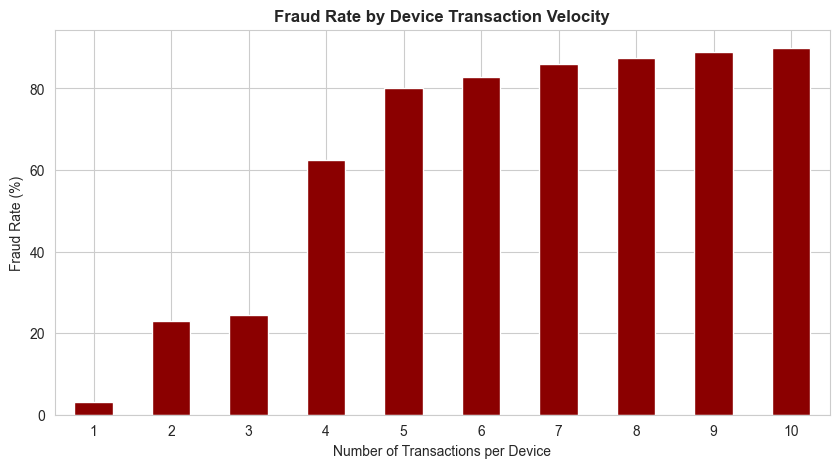


Single-transaction devices: 3.04% fraud rate
Devices with 3+ transactions: 85.15% fraud rate


In [18]:
device_risk = df.groupby('device_tx_velocity')['class'].mean() * 100
plt.figure(figsize=(10, 5))
device_risk.head(10).plot(kind='bar', color='darkred')
plt.title('Fraud Rate by Device Transaction Velocity', fontsize=12, fontweight='bold')
plt.xlabel('Number of Transactions per Device')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.show()

print(f"\nSingle-transaction devices: {device_risk[1]:.2f}% fraud rate")
if len(device_risk) > 2:
    print(f"Devices with 3+ transactions: {device_risk[device_risk.index >= 3].mean():.2f}% fraud rate")

GEOGRAPHIC PATTERNS

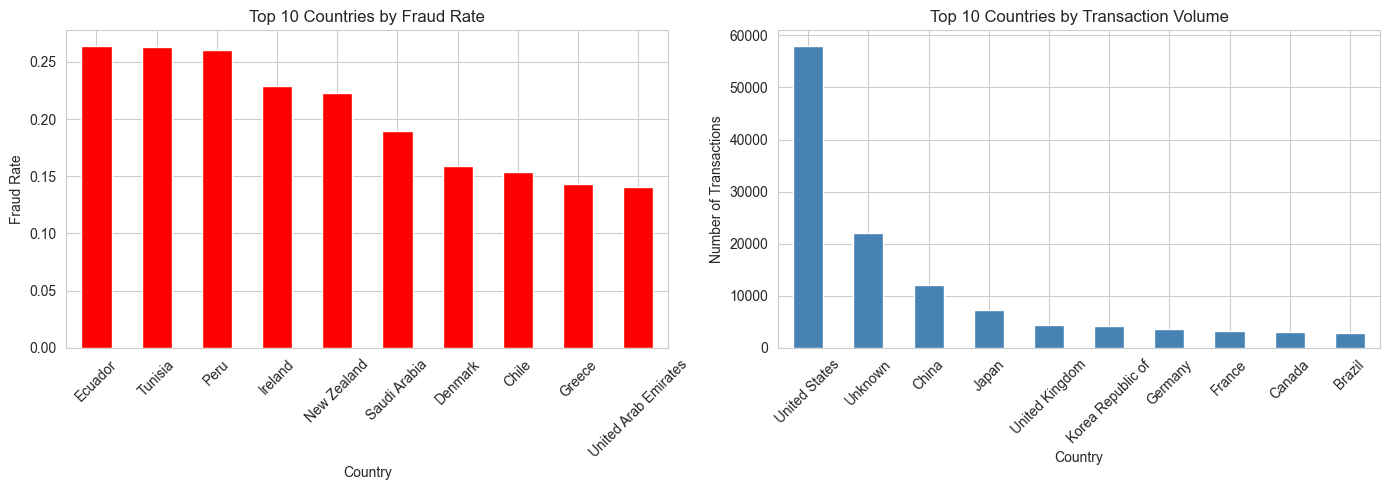

In [19]:

# Cell: Top fraud countries
country_risk = df.groupby('country')['class'].agg(['count', 'mean']).round(4)
country_risk = country_risk[country_risk['count'] > 100]  # Minimum 100 transactions
country_risk = country_risk.sort_values('mean', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by country
country_risk.head(10)['mean'].plot(kind='bar', ax=ax1, color='red')
ax1.set_title('Top 10 Countries by Fraud Rate')
ax1.set_xlabel('Country')
ax1.set_ylabel('Fraud Rate')
ax1.tick_params(axis='x', rotation=45)

# Transaction volume by country
df['country'].value_counts().head(10).plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Top 10 Countries by Transaction Volume')
ax2.set_xlabel('Country')
ax2.set_ylabel('Number of Transactions')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()